<a href="https://colab.research.google.com/github/KaterinaSor2005/homework_Sorokina332/blob/main/hw5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
Лучшая точность на кросс-валидации: 0.9865
Точность на тесте (KNN): 0.9833


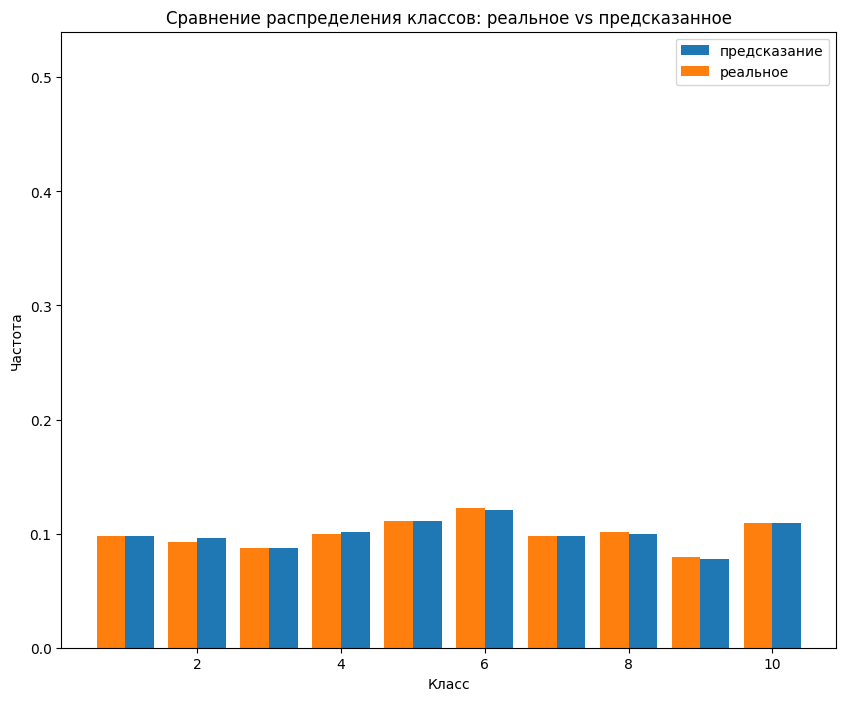

Точность на тесте (LogReg): 0.9685


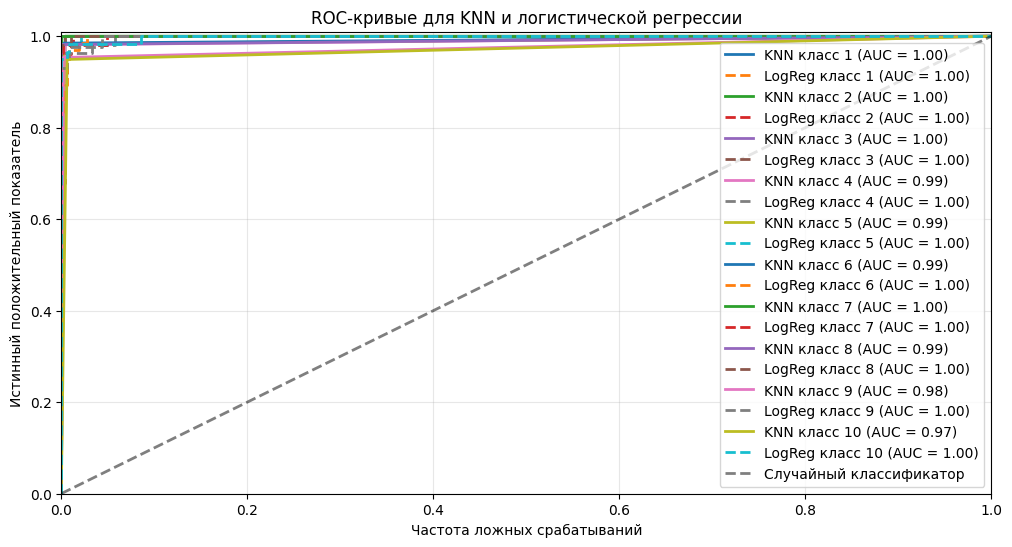


AUC-ROC (микро):
KNN: 0.9907
LogReg: 0.9991

AUC-ROC (макро):
KNN: 0.9908
LogReg: 0.9990

ВЫВОДЫ
1. Качество KNN на тесте: accuracy = 0.9833
2. Качество логистической регрессии: accuracy = 0.9685
   KNN показывает более высокую точность, чем логистическая регрессия.

3. Плюсы и минусы метода k ближайших соседей:
   Плюсы:
     - Простота реализации и интерпретации.
     - Не делает предположений о распределении данных.
     - Может работать со сложными границами классов.
   Минусы:
     - Вычислительно затратен на этапе предсказания (нужно хранить всю выборку).
     - Чувствителен к масштабу признаков и выбросам.
     - Требует выбора оптимального k и метрики расстояния.
     - Страдает от проклятия размерности (при большом числе признаков).

4. Сравнение по AUC-ROC:
   Микро-усреднение: KNN = 0.9907, LogReg = 0.9991
   Макро-усреднение: KNN = 0.9908, LogReg = 0.9990
   Логистическая регрессия имеет более высокую разделяющую способность по AUC-ROC.


In [13]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
%matplotlib inline

clf = KNeighborsClassifier()

params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}


clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(X_train, y_train)

print("Лучшие параметры:", clf_grid.best_params_)
print("Лучшая точность на кросс-валидации: {:.4f}".format(clf_grid.best_score_))

optimal_clf = clf_grid.best_estimator_
optimal_clf.fit(X_train, y_train)

pred_prob = optimal_clf.predict_proba(X_test)

y_pred = optimal_clf.predict(X_test)


test_acc = accuracy_score(y_test, y_pred)
print("Точность на тесте (KNN): {:.4f}".format(test_acc))


unique, freq = np.unique(y_test, return_counts=True)
freq = freq / len(y_test)

pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(range(1, len(unique)+1), pred_freq, width=0.4, align="edge", label='предсказание')
plt.bar(range(1, len(unique)+1), freq, width=-0.4, align="edge", label='реальное')
plt.ylim(0, 0.54)
plt.xlabel("Класс")
plt.ylabel("Частота")
plt.legend()
plt.title("Сравнение распределения классов: реальное vs предсказанное")
plt.show()


lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
test_acc_lr = accuracy_score(y_test, y_pred_lr)
print("Точность на тесте (LogReg): {:.4f}".format(test_acc_lr))


y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]


pred_prob_knn = optimal_clf.predict_proba(X_test)


pred_prob_lr = lr.predict_proba(X_test)

plt.figure(figsize=(12, 6))

for i in range(n_classes):
    fpr_knn, tpr_knn, _ = roc_curve(y_test_bin[:, i], pred_prob_knn[:, i])
    roc_auc_knn = auc(fpr_knn, tpr_knn)
    plt.plot(fpr_knn, tpr_knn, lw=2, label=f'KNN класс {i+1} (AUC = {roc_auc_knn:.2f})')

    fpr_lr, tpr_lr, _ = roc_curve(y_test_bin[:, i], pred_prob_lr[:, i])
    roc_auc_lr = auc(fpr_lr, tpr_lr)
    plt.plot(fpr_lr, tpr_lr, lw=2, linestyle='--', label=f'LogReg класс {i+1} (AUC = {roc_auc_lr:.2f})')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Случайный классификатор')

plt.xlabel('Частота ложных срабатываний')
plt.ylabel('Истинный положительный показатель')
plt.title('ROC-кривые для KNN и логистической регрессии')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

micro_auc_knn = roc_auc_score(y_test_bin, pred_prob_knn, average='micro', multi_class='ovr')
macro_auc_knn = roc_auc_score(y_test_bin, pred_prob_knn, average='macro', multi_class='ovr')
micro_auc_lr = roc_auc_score(y_test_bin, pred_prob_lr, average='micro', multi_class='ovr')
macro_auc_lr = roc_auc_score(y_test_bin, pred_prob_lr, average='macro', multi_class='ovr')

print("\nAUC-ROC (микро):")
print(f"KNN: {micro_auc_knn:.4f}")
print(f"LogReg: {micro_auc_lr:.4f}")
print("\nAUC-ROC (макро):")
print(f"KNN: {macro_auc_knn:.4f}")
print(f"LogReg: {macro_auc_lr:.4f}")

print("\n" + "="*50)
print("ВЫВОДЫ")
print("="*50)
print(f"1. Качество KNN на тесте: accuracy = {test_acc:.4f}")
print(f"2. Качество логистической регрессии: accuracy = {test_acc_lr:.4f}")
if test_acc > test_acc_lr:
    print("   KNN показывает более высокую точность, чем логистическая регрессия.")
elif test_acc < test_acc_lr:
    print("   Логистическая регрессия показывает более высокую точность, чем KNN.")
else:
    print("   Модели показали одинаковую точность.")

print("\n3. Плюсы и минусы метода k ближайших соседей:")
print("   Плюсы:")
print("     - Простота реализации и интерпретации.")
print("     - Не делает предположений о распределении данных.")
print("     - Может работать со сложными границами классов.")
print("   Минусы:")
print("     - Вычислительно затратен на этапе предсказания (нужно хранить всю выборку).")
print("     - Чувствителен к масштабу признаков и выбросам.")
print("     - Требует выбора оптимального k и метрики расстояния.")
print("     - Страдает от проклятия размерности (при большом числе признаков).")

print("\n4. Сравнение по AUC-ROC:")
print(f"   Микро-усреднение: KNN = {micro_auc_knn:.4f}, LogReg = {micro_auc_lr:.4f}")
print(f"   Макро-усреднение: KNN = {macro_auc_knn:.4f}, LogReg = {macro_auc_lr:.4f}")
if micro_auc_knn > micro_auc_lr:
    print("   KNN имеет более высокую разделяющую способность по AUC-ROC.")
else:
    print("   Логистическая регрессия имеет более высокую разделяющую способность по AUC-ROC.")